In [5]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.modeling.models import Lorentz1D

# plasma stuff
nc = 3.53*10**21 # critical density [cm^-3]
n_max = 2*10**17 # peak plasma density [cm^-3]
L = 1 # 1 cm pinch diameter
pr = L/2 # pinch radius



a = 1 # mm
C = 0.05 # contrast
B = 124 # through put of light source (background light intensity level)
b = 2 # width of light source aperature in mm
f = 4000 # focal length of schlieren mirror [mm]


r = np.linspace(-1.5,1.5,100) # impact parameter
n = []

# # parablic density profile
# for radius in r:
#     if abs(radius) <= pr:
#         n.append(-10**17/pr**2*radius**2 + n_max)
#     else:
#         n.append(0)

# lorentz density profile
lorentz = Lorentz1D(n_max,fwhm=pr)
n = lorentz(r)


# convert density to refractive index
N = (1-n/nc)**(1/2)
# take transverse gradient (DN/dy) where dy is dr
dNdy = np.gradient(N,r)
# minimum schlieren sensitivity
dNdy_min = C*a/(L*f)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(r,n, color = 'magenta')
ax2.plot(r,np.abs(dNdy), color = 'black')
ax2.axhline(dNdy_min, color = 'black', linestyle = 'dashed')
ax1.set_ylabel(r'Plasma Density [cm$^{-3}$]', color = 'magenta')
ax2.set_ylabel('Change in Refractive Index')
ax1.set_title('Plasma Refractive Index vs Impact Parameter')
ax1.set_xlabel('Impact Parameter [cm]')
ax2.legend([r'$\Delta$N', 'Schlieren \nminimum \nsensitivity'], loc = 'upper right')
plt.show()

cL =[]
for radius in r:
    if abs(radius) <= pr:
        cL.append(2*np.sqrt(pr**2-abs(radius)**2)) # chord length across the pinch
    else:
        cL.append(0)
cL = np.array(cL) # path length through the plasma for each ray dependent of y

epy = cL*dNdy # ray deflection angle (or proportional to it)
dE = B*b*epy/f # intensity change
E = [B]*len(dE)

image = []
for column in range(400):
    image.append(E+dE)
    
image = np.array(image)
ytick_locs = [0,25,50,75,100]
ytick_labels = [-15,-7.5,0,7.5,15]
plt.figure()
plt.imshow(image.T,  cmap = 'gray', origin = 'lower')
ax = plt.gca()
ax.set_yticks(ytick_locs)
ax.set_yticklabels(ytick_labels)
ax.invert_xaxis()
plt.title('Synthetic Schliere:\n 1 cm Dia., Lorentz Profile Peaked at 2*10$^{17}$ cm$^{-3}$')
plt.xlabel('Impact Parameter [mm]')
plt.ylabel('Impact Parameter [mm]')
plt.show()

idx = np.where(np.abs(dNdy) < dNdy_min)[0]


AttributeError: module 'numpy' has no attribute 'in1d'

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def lorentz_profile(r, amplitude, fwhm, x0=0.0):
    gamma = 0.5 * fwhm
    return amplitude * gamma**2 / ((r - x0)**2 + gamma**2)


def synthetic_schlieren_axisymmetric(
    y_cm: np.ndarray,
    *,
    pr_cm: float=0.5, # pinch radius [cm]
    nc_cm3: float=3.53e21, # critical density [cm^-3]
    n_max: float=2e17, # peak plasma density [cm^-3]
    B: float=124.0, # baseline brightness
    b_mm: float=2.0, # width of light source aperature [mm]
    f_mm: float=4000.0, # schlieren mirror focal length [mm]
    nz: int=400, # image width in pixels (z axis)
    nx: int=1200, # line of sight integration resolution
    use_1_over_N: bool=True, # include (1/N)*dN/dy in deflection integral
    clip_N: bool=True, # keep N real for n<=nc
):
    """
    build a simple synthetic schlieren image for an axisymmetric plasma column

    workflow
      n(r) -> N(r)=sqrt(1 - n/nc)
      N(r) -> dN/dr
      dN/dr -> dN/dy along each line of sight
      theta(y) ~ integral{ (1/N) (dN/dy) dz }
      I(y) = B + (B*b/f)*theta(y)
      Image = repeat I(y) across z

    returns:
      y_cm, theta_y, I_y, image (shape: [len(y_cm), nz]), dNdy, z
      plus radial profiles: r_1d, n_1d, N_1d, dNdr_1d
    """

    # convert to cm
    b_cm = b_mm / 10.0
    f_cm = f_mm / 10.0

    # build x grid for line of sight integration ie for each ray at y rays go from -xmax to xmax
    xmax_cm = pr_cm
    x = np.linspace(-xmax_cm, xmax_cm, nx)
    dx = x[1] - x[0]

    # 2d grids for r(y, x) and mask inside pinch
    Y = y_cm[:, None] # shape (Ny, 1)
    X = x[None, :] # shape (1, Nx)
    R = np.sqrt(Y**2 + X**2) # shape (Ny, Nx)
    inside = R <= pr_cm

    # evaluate Lorentz density profile n(r) on (y, x) grid
    n_r = lorentz_profile(R, n_max, pr_cm)
    n_r = np.where(inside, n_r, 0.0)

    # convert density --> refractive index N(r)
    inside_sqrt = 1.0 - (n_r / nc_cm3)
    if clip_N:
        # prevent negative inside sqrt due to numerical/parameter choices
        inside_sqrt = np.clip(inside_sqrt, 1e-12, None)
    N_r = np.sqrt(inside_sqrt)

    # compute dN/dr, radial gradient of refractive index
    r_1d = np.linspace(0.0, pr_cm, max(400, int(nx/2)))
    n_1d = np.where(r_1d <= pr_cm, lorentz_profile(r_1d, n_max, pr_cm), 0.0)
    inside_sqrt_1d = 1.0 - (n_1d / nc_cm3)
    if clip_N:
        inside_sqrt_1d = np.clip(inside_sqrt_1d, 1e-12, None)
    N_1d = np.sqrt(inside_sqrt_1d)
    dNdr_1d = np.gradient(N_1d, r_1d)

    # sample dN/dr at each R 
    dNdr = np.interp(R, r_1d, dNdr_1d)
    dNdr = np.where(inside, dNdr, 0.0)

    # convert radial gradient to transverse gradient dN/dy because this is what we see from line of sight
    eps = 1e-12
    dNdy = dNdr * (Y / (R+eps))
    dNdy = np.where(inside, dNdy, 0.0)

    # intuition for getting accurate ray deflection from transverse gradient:
    # deflection of ray proportional to time spent in plasma (chord length) x sideways gradient (dN/dy) <-- this is what Jared does
    # ^ just an approximation BECAUSE: as the ray travels through x...
    #      - radius from axis changes
    #      - therefore local density changes
    #      - therefore local refractive index changes
    #      - therefore local gradient changes
    # so we should instead imagine ray path having tiny segments dx with local transverse gradients causing angular change dtheta:
    # dtheta = (1/N)(dN/dy)dx ... refractive index in the denominator accounts for ray speed in the medium

    integrand = dNdy / (N_r+eps) #if use_1_over_N else dNdy
    theta_y = np.sum(integrand, axis=1) * dx # shape (Ny,)

    # map deflection to intensity change
    I_y = B + (B * (b_cm / f_cm)) * theta_y
    # build 2D image by repeating I(y) across x, so intensity varies only with y
    image = np.repeat(I_y[:,None], nz, axis=1) # shape (Ny, nz)


    return y_cm, theta_y, I_y, image, r_1d, n_1d, N_1d, dNdr_1d, dNdy, N_r, x

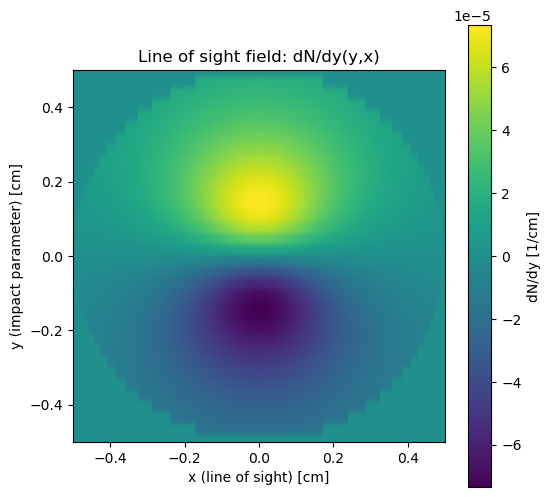

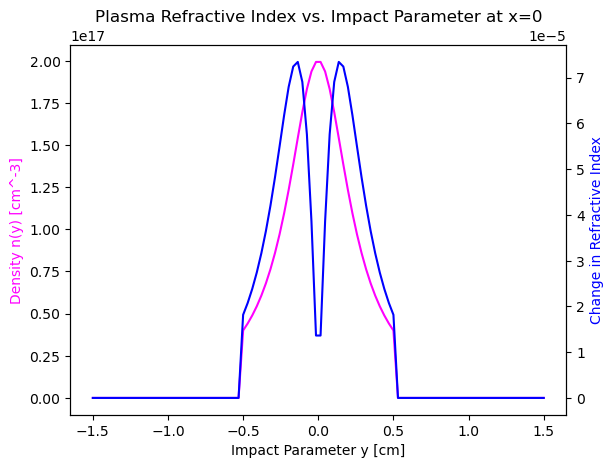

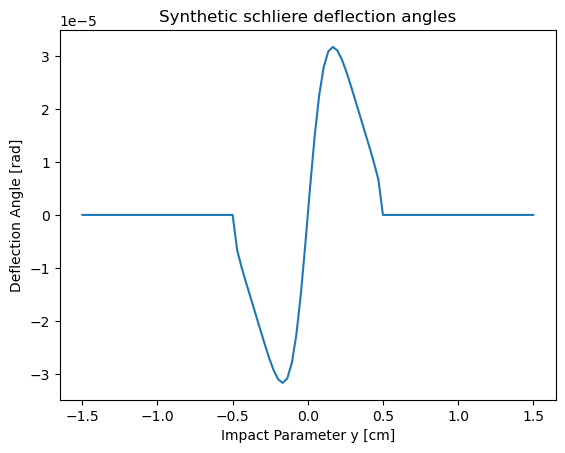

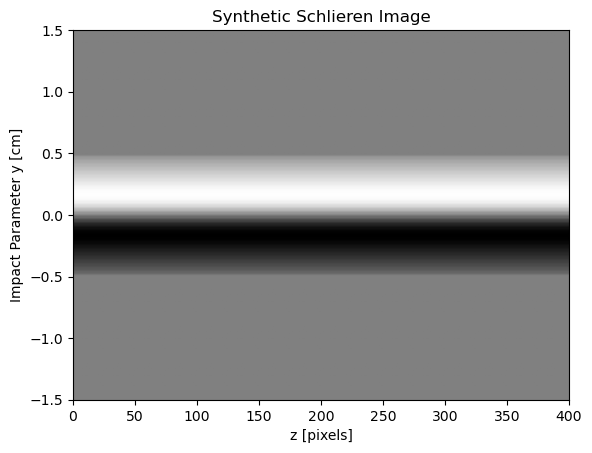

Text(0, 0.5, 'Refractive Index N(r)')

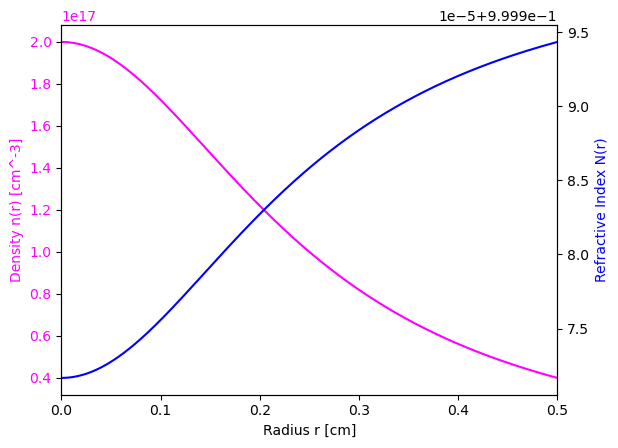

In [14]:
y_cm = np.linspace(-1.5, 1.5, 100)
pr_cm = 0.5

y_cm, theta_y, I_y, img, r_1d, n_1d, N_1d, dNdr_1d, dNdy, N_r, x = synthetic_schlieren_axisymmetric(y_cm)


# minimum schlieren sensitivity
a = 0.1 # height of light let over the cutoff in cm
C = 0.05 # contrast of schlieren system
L = 2*pr_cm # pinch diameter in cm
f = 200 # focal length in cm
dNdy_min = C*a/(L*f)

# map n(r) onto the transverse coordinate y
# for axisymmetric plasma, at the midplane x = 0 we have r = |y|
# this lets us visualize density as a function of impact parameter y
n_on_y = np.interp(np.abs(y_cm), r_1d, n_1d)
# physically enforce the plasma boundary
n_on_y[np.abs(y_cm) > pr_cm] = 0.0

# map dN/dr onto y using r = |y|
# this gives the magnitude of the gradient at the corresponding radius
dNdr_on_y = np.interp(np.abs(y_cm), r_1d, dNdr_1d)
# physically enforce the plasma boundary
dNdr_on_y[np.abs(y_cm) > pr_cm] = 0.0
# convert the radial gradient into a transverse gradient dN/dy
# using the chain rule:
#   dN/dy = (dN/dr) * (dr/dy)
# at x = 0, r = |y| so dr/dy = sign(y)
# this assigns the correct direction (left/right) of the gradient
dNdy_on_y = dNdr_on_y * np.sign(y_cm)

# same for N_1d
N_on_y = np.interp(np.abs(y_cm), r_1d, N_1d)
N_on_y[np.abs(y_cm) > pr_cm] = 1.0

# plot 1 - dNdy for z slice
plt.figure(figsize=(6, 6))
plt.imshow(
    dNdy,
    origin="lower",
    aspect="equal",
    extent=[x.min(), x.max(), y_cm.min(), y_cm.max()]  # use the real coords
)
plt.colorbar(label="dN/dy [1/cm]")
plt.xlabel("x (line of sight) [cm]")
plt.ylabel("y (impact parameter) [cm]")
plt.title("Line of sight field: dN/dy(y,x)")
plt.xlim(-pr_cm, pr_cm)
plt.ylim(-pr_cm, pr_cm)
plt.show()

# plot 2 - density and refractive index gradient at a slice x=0
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(y_cm, n_on_y, color='magenta')
ax2.plot(y_cm, np.abs(dNdy_on_y), color='blue')
#ax2.axhline(dNdy_min, color = 'black', linestyle = 'dashed')
ax1.set_xlabel("Impact Parameter y [cm]")
ax1.set_ylabel("Density n(y) [cm^-3]", color='magenta')
ax2.set_ylabel("Change in Refractive Index", color='blue')
ax1.set_title("Plasma Refractive Index vs. Impact Parameter at x=0")
#ax2.legend([r'$\Delta$N', 'Schlieren \nminimum \nsensitivity'], loc = 'upper right')
plt.show()

fig, ax1 = plt.subplots()
ax1.plot(y_cm, theta_y)
ax1.set_xlabel("Impact Parameter y [cm]")
ax1.set_ylabel("Deflection Angle [rad]")
ax1.set_title("Synthetic schliere deflection angles")
plt.show()


# plot 3 - synthetic schlieren image
plt.figure()
plt.imshow(img, cmap="gray", origin="lower", aspect="auto",
           extent=[0, img.shape[1], y_cm[0], y_cm[-1]])
plt.xlabel("z [pixels]")
plt.ylabel("Impact Parameter y [cm]")
plt.title("Synthetic Schlieren Image")
plt.show()

# plot 4 - true radial profiles n(r) and N(r)
fig, ax1 = plt.subplots()

ax1.plot(r_1d, n_1d, color="magenta", label="n(r)")
ax1.set_xlabel("Radius r [cm]")
ax1.set_ylabel("Density n(r) [cm^-3]", color="magenta")
ax1.tick_params(axis="y", labelcolor="magenta")
ax1.set_xlim(0, pr_cm)

ax2 = ax1.twinx()
ax2.plot(r_1d, N_1d, color="blue", label="N(r)")
ax2.set_ylabel("Refractive Index N(r)", color="blue")


In [26]:
theta_max = np.max(np.abs(theta_y))  # rad

# pick the max ray height on the lens you can practically use
r_max_mm = 12.7 /2  # mm
#f_m = (r_max_mm * 1e-3) / theta_max
print("theta_max [rad] =", theta_max)

# or: given a lens focal length, what r is needed?
f_m = 20
r_needed_mm = theta_max * f_m * 1e3
print("For f=20 m (largest I can find), r needed to see max deflection angles from plasma [mm] =", r_needed_mm)
print("This is", (r_needed_mm/r_max_mm)*100, "% of lens diameter")

theta_max [rad] = 3.169081573284781e-05
For f=20 m (largest I can find), r needed to see max deflection angles from plasma [mm] = 0.6338163146569562
This is 9.981359285936318 % of lens diameter


In [ ]:
def intensity_to_theta(img, y_cm, *, pr_cm=0.5, B=124.0, b_mm=2.0, f_mm=4000.0, eps=1e-12):
    # sort by y
    s = np.argsort(y_cm)
    y = np.asarray(y_cm)[s]
    I = img[s, :].astype(np.float64)

    # mask outside plasma to baseline
    I = I.copy()
    I[np.abs(y) > pr_cm, :] = B

    # average across x
    I_y = I.mean(axis=1)

    # convert to theta
    b_cm = b_mm / 10.0
    f_cm = f_mm / 10.0
    k = B * (b_cm / f_cm)
    theta_y_back = (I_y - B) / (k + eps)

    return y, theta_y_back

# backward theta from image
y_sorted, theta_back = intensity_to_theta(img, y_cm)


# plot comparison
plt.figure()
plt.plot(y_sorted, theta_y, label="Forward theta_y (from synthetic)")
plt.plot(y_sorted, theta_back, "--", label="Backward theta(y) from image")
plt.xlabel("y [cm]")
plt.ylabel("theta [rad] (small-angle)")
plt.title("Theta consistency check: forward vs backward")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

# optional: print max absolute difference
print("max |theta_forward - theta_back| =", np.max(np.abs(theta_y - theta_back)))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _cumtrapz_1d(f, x):
    """
    Cumulative trapezoid integral of f(x) over x.
    Returns F with F[0]=0 and F[i] = ∫_{x0}^{xi} f(x') dx'
    """
    f = np.asarray(f, dtype=float)
    x = np.asarray(x, dtype=float)
    dx = np.diff(x)
    return np.concatenate([[0.0], np.cumsum(0.5 * (f[1:] + f[:-1]) * dx)])

def reconstruct_areal_logN_from_theta(
    y_sorted,
    theta_back,     
    *,
    pr_cm,
    N_r,      # 2D array shaped (Ny, Nx) corresponding to y_sorted and x grid
    x,        # 1D line of sight grid (cm), length Nx
    eps=1e-12,
    baseline_mode="outside_mean",  # or "edge_mean"
):
    """
    Reconstruct areal log refractive index profile:
      N_log_back(y) = ∫ theta_back(y) dy  (+ constant)
    and compute forward comparator:
      N_log_fwd(y)  = ∫ ln(N_r(y,x)) dx   (baseline removed)

    Returns:
      N_log_fwd, N_log_back, N_areal_fwd=exp(N_log_fwd), N_areal_back=exp(N_log_back)
    """

    y = np.asarray(y_sorted, dtype=float)
    th = np.asarray(theta_back, dtype=float)

    # ---- Backward: integrate theta over y to get N_log (up to constant)
    N_log_back_raw = _cumtrapz_1d(th, y)

    # ---- Forward: integrate ln(N) along line of sight x
    # protect log
    N_safe = np.clip(N_r, eps, None)
    lnN = np.log(N_safe)
    N_log_fwd_raw = np.trapz(lnN, x, axis=1)  # integrates along x for each y

    # ---- Choose baseline region (outside plasma) to set "zero"
    outside = np.abs(y) > pr_cm

    if baseline_mode == "outside_mean":
        if np.any(outside):
            b_back = np.mean(N_log_back_raw[outside])
            b_fwd  = np.mean(N_log_fwd_raw[outside])
        else:
            # fallback if y range doesn't include outside region
            b_back = N_log_back_raw[0]
            b_fwd  = N_log_fwd_raw[0]
    elif baseline_mode == "edge_mean":
        # use a small band near |y| ~ pr_cm
        band = (np.abs(y) > 0.9*pr_cm) & (np.abs(y) < 1.1*pr_cm)
        if np.any(band):
            b_back = np.mean(N_log_back_raw[band])
            b_fwd  = np.mean(N_log_fwd_raw[band])
        else:
            b_back = N_log_back_raw[0]
            b_fwd  = N_log_fwd_raw[0]
    else:
        raise ValueError("baseline_mode must be 'outside_mean' or 'edge_mean'")

    # Baseline-shift so outside plasma ~ 0
    N_log_back = N_log_back_raw - b_back
    N_log_fwd  = N_log_fwd_raw  - b_fwd

    # Optionally enforce exact 0 outside (helps visual sanity)
    N_log_back = N_log_back.copy()
    N_log_fwd = N_log_fwd.copy()
    N_log_back[outside] = 0.0
    N_log_fwd[outside]  = 0.0

    # Convert to "areal refractive index factor" (relative): exp(areal logN)
    N_areal_back = np.exp(N_log_back)
    N_areal_fwd  = np.exp(N_log_fwd)

    return N_log_fwd, N_log_back, N_areal_fwd, N_areal_back


# y_sorted, theta_back already computed by intensity_to_theta(img, y_cm)

# Reconstruct areal profiles
N_log_fwd, N_log_back, N_areal_fwd, N_areal_back = reconstruct_areal_logN_from_theta(
    y_sorted, theta_back,
    pr_cm=pr_cm,
    N_r=N_r,   
    x=x,
)

plt.figure()
plt.plot(y_sorted, N_log_fwd, label="Forward areal N_log(y) = ∫ ln(N) dx")
plt.plot(y_sorted, N_log_back, "--", label="Backward areal N_log(y) = ∫ theta dy")
plt.xlabel("y [cm]")
plt.ylabel("N_log(y) [cm]") # plt.ylabel("N_log(y) [cm] (relative, baseline-shifted)")
plt.title("Areal log refractive index profile: forward vs backward")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure()
plt.plot(y_sorted, N_areal_fwd, label="Forward exp(N_log)")
plt.plot(y_sorted, N_areal_back, "--", label="Backward exp(N_log)")
plt.xlabel("y [cm]")
plt.ylabel("exp(N_log(y)) (relative)")
plt.title("Areal refractive index factor: forward vs backward")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("max |N_log_fwd - N_log_back| =", np.max(np.abs(N_log_fwd - N_log_back)))


In [ ]:
# best-fit scale factor between forward and backward
mask = np.abs(y_cm) <= pr_cm
alpha = np.dot(N_log_fwd[mask], N_log_back[mask]) / np.dot(N_log_back[mask], N_log_back[mask])

plt.figure()
plt.plot(y_cm, N_log_fwd, label="forward")
plt.plot(y_cm, alpha*N_log_back, "--", label=f"backward × {alpha:.2f}")
plt.legend()
plt.title("Shape match after optimal scaling")
plt.show()